In [32]:
import pandas as pd
import numpy as np


In [33]:
df=pd.read_csv("/content/TISC Historical Data (1).csv")

In [34]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,01-07-2021,116.36,117.19,117.68,115.64,56.15M,-0.26%
1,30-06-2021,116.66,118.11,119.10,116.28,80.43M,-0.51%
2,29-06-2021,117.25,118.45,119.20,116.56,78.04M,-0.97%
3,28-06-2021,118.40,117.40,118.90,116.30,116.60M,1.61%
4,25-06-2021,116.53,113.50,117.00,113.00,180.23M,4.68%
...,...,...,...,...,...,...,...
4995,29-05-2001,7.68,7.71,7.79,7.65,40.32M,0.26%
4996,28-05-2001,7.66,7.45,7.71,7.45,57.95M,3.23%
4997,25-05-2001,7.42,7.49,7.55,7.40,18.76M,-0.80%
4998,24-05-2001,7.48,7.50,7.58,7.44,32.93M,0.27%


## Standard Model Workflow (without Random Search)

This section contains the code for loading data, preprocessing, building and training a TensorFlow model with manually set hyperparameters, evaluating the model, saving it, and making predictions.

In [179]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler # Changed to RobustScaler
from sklearn.model_selection import train_test_split
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv("/content/TISC Historical Data (1).csv")

# Remove unnecessary columns
df = df.drop(['Date','Price','Vol.','Change %'],axis=1)

# Separate features (X) and target (y)
X = df[['Open', 'Low']]
y = df[['High']]

# Initialize and fit the scaler on the features (X)
scaler_X = RobustScaler() # Using RobustScaler
X_scaled = scaler_X.fit_transform(X)

# Initialize and fit a separate scaler on the target (y)
scaler_y = RobustScaler() # Using RobustScaler
y_scaled = scaler_y.fit_transform(y)

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Save the scalers
joblib.dump(scaler_X, 'scaler_X_standard.pkl')
joblib.dump(scaler_y, 'scaler_y_standard.pkl')

print("Data loading, preprocessing, and splitting complete. Scalers saved.")

Data loading, preprocessing, and splitting complete. Scalers saved.


### Build and Train the Model

Using manually set hyperparameters.

In [180]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Manually set hyperparameters (example values)
epochs = 150
batch_size = 32 # Reduced batch size
neurons = (256, 128, 64)
learning_rate = 0.001
dropout_rate = 0.1

# Create the Sequential model with Dense layers and Dropout
model = Sequential()
model.add(Dense(neurons[0], activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(dropout_rate)) # Added Dropout layer
model.add(Dense(neurons[1], activation='relu'))
model.add(Dropout(dropout_rate)) # Added Dropout layer
model.add(Dense(neurons[2], activation='relu'))
model.add(Dense(1))

# Compile the model
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mse')

# Train the model
print(f"Training model with manually set hyperparameters and Dropout: Epochs={epochs}, Batch Size={batch_size}, Neurons={neurons}, Learning Rate={learning_rate}, Dropout Rate={dropout_rate}")
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)

print("Model training complete.")

Training model with manually set hyperparameters and Dropout: Epochs=150, Batch Size=32, Neurons=(256, 128, 64), Learning Rate=0.001, Dropout Rate=0.1
Epoch 1/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0818
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033
Epoch 8/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034
Epoch 9/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027
Epoch 10/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028
Epoch 11/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030
Epoch 12/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029
Epoch 13/150
125/125 ━━━━━━━━━

In [182]:

# check training and testing accuracy to find overfit or under fit
train_loss = model.evaluate(X_train, y_train, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)
# Evaluate the model
loss = model.evaluate(X_test, y_test, verbose=0)

# Print the evaluation metric
print(f'Model loss on testing data: {loss}')
print(f'Training Loss: {train_loss}')
print(f'Testing Loss: {test_loss}' )
# check r2 score
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
# check mse and mae
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')

Model loss on testing data: 0.003480015555396676
Training Loss: 0.0035576745867729187
Testing Loss: 0.003480015555396676
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
R2 Score: 0.9947441526786569
Mean Squared Error: 0.003480015671253312
Mean Absolute Error: 0.048036856769340684


### Save the Model and Scalers

In [183]:
# Save the trained model
model.save('stock_price_model_standard.keras')
print("Model saved successfully.")

# Scalers were already saved in the data preprocessing step.

Model saved successfully.


### Load Model and Make Predictions

Code to take user input and predict using the standard model.

In [187]:
import tensorflow as tf
import numpy as np
import joblib

# Load the saved model
loaded_model_standard = tf.keras.models.load_model('stock_price_model_standard.keras')
print("Standard model loaded successfully.")

# Load the saved scalers
scaler_X_standard = joblib.load('scaler_X_standard.pkl')
scaler_y_standard = joblib.load('scaler_y_standard.pkl')
print("Standard scalers loaded successfully.")

# Get user input for 'Open' and 'Low'
try:
    open_price = float(input("Enter the 'Open' price: "))
    low_price = float(input("Enter the 'Low' price: "))
except ValueError:
    print("Invalid input. Please enter numeric values.")
    # Exit or handle the error as needed, for now just print and continue
    # exit()

# Create a NumPy array from user input
user_input = np.array([[open_price, low_price]])

# Scale the user input
user_input_scaled = scaler_X_standard.transform(user_input)

# Make a prediction using the loaded model
scaled_prediction = loaded_model_standard.predict(user_input_scaled)

# Inverse transform the scaled prediction
predicted_high_price = scaler_y_standard.inverse_transform(scaled_prediction)

# Print the predicted 'High' price
print(f"\nPredicted 'High' price: {predicted_high_price[0][0]}")

Standard model loaded successfully.
Standard scalers loaded successfully.
Enter the 'Open' price: 154.48
Enter the 'Low' price: 153.70
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Predicted 'High' price: 155.7626953125


## Analyze Model Predictions on Test Data

### Subtask:
Make predictions on the test dataset using the standard model and compare them with the actual 'High' prices.

**Reasoning**:
Use the trained standard model to predict 'High' prices for the scaled test features (`X_test`), inverse transform the predictions and actual values, and then display or visualize the comparison to assess the model's performance on unseen data.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Comparison of Actual vs. Predicted 'High' Prices on Test Data:


,Actual High,Predicted High
0,27.58,28.175861
1,56.97,57.838783
2,58.58,58.876678
3,43.30,44.534721
4,58.49,59.171162
5,66.18,66.004143
6,49.72,49.555264
7,51.98,52.695232
8,36.67,37.702850
9,35.79,37.138367


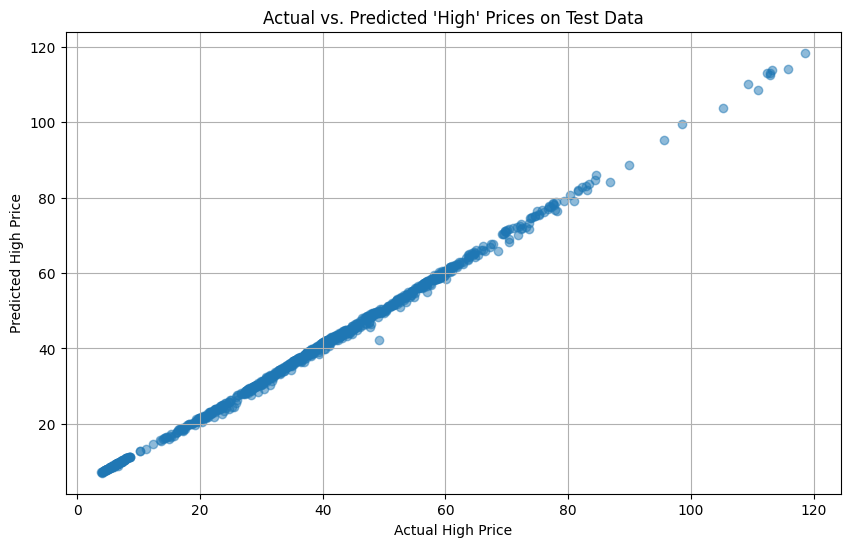

In [186]:
# Make predictions on the test set
y_pred_scaled = loaded_model_standard.predict(X_test)

# Inverse transform the scaled predictions and actual values
y_pred_original = scaler_y_standard.inverse_transform(y_pred_scaled)
y_test_original = scaler_y_standard.inverse_transform(y_test)

# Display a comparison of actual vs. predicted prices
comparison_df = pd.DataFrame({'Actual High': y_test_original.flatten(), 'Predicted High': y_pred_original.flatten()})
print("Comparison of Actual vs. Predicted 'High' Prices on Test Data:")
display(comparison_df.head(20))

# Optionally, visualize the comparison (e.g., scatter plot or line plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.xlabel("Actual High Price")
plt.ylabel("Predicted High Price")
plt.title("Actual vs. Predicted 'High' Prices on Test Data")
plt.grid(True)
plt.show()